   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3     low  
4 

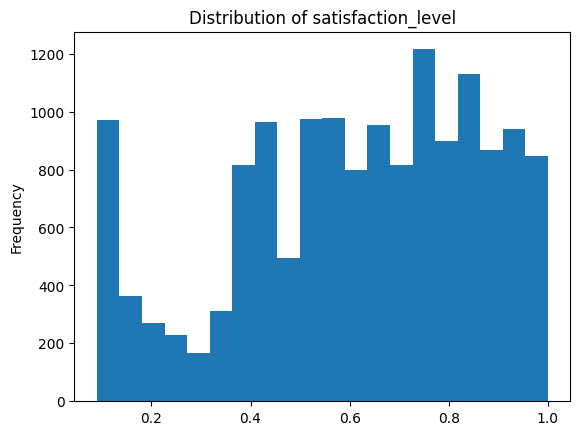

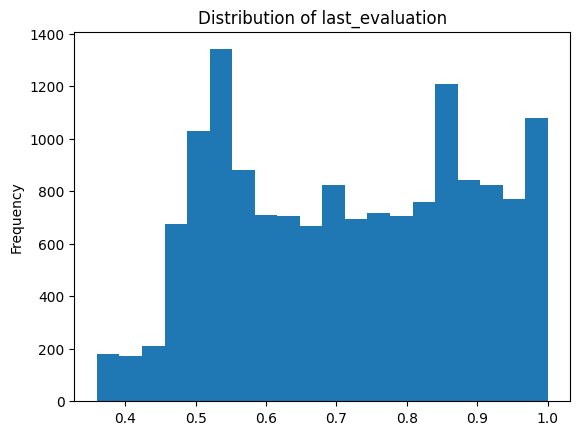

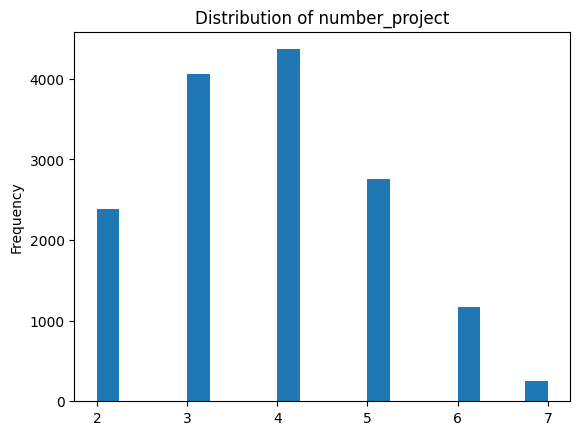

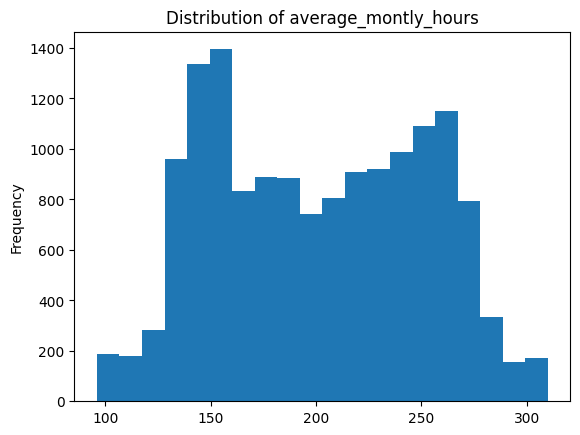

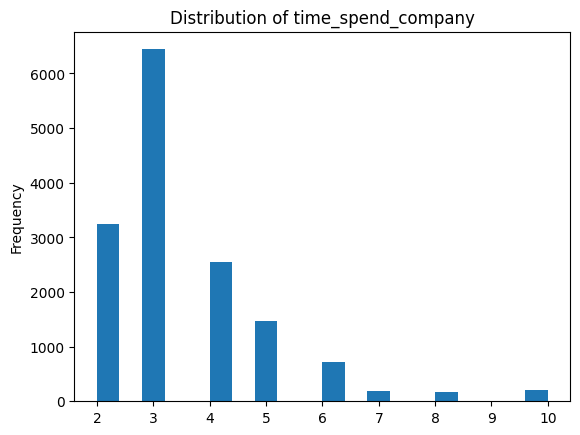

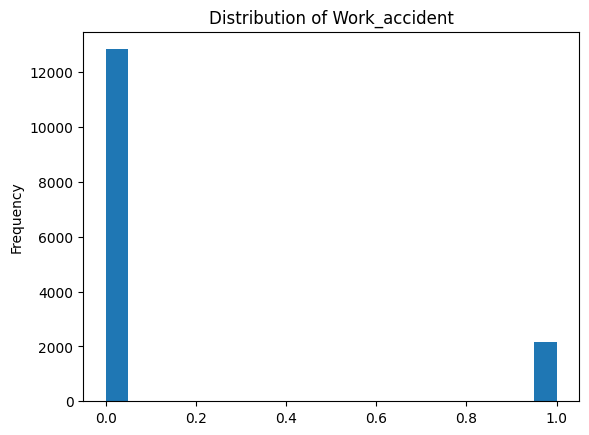

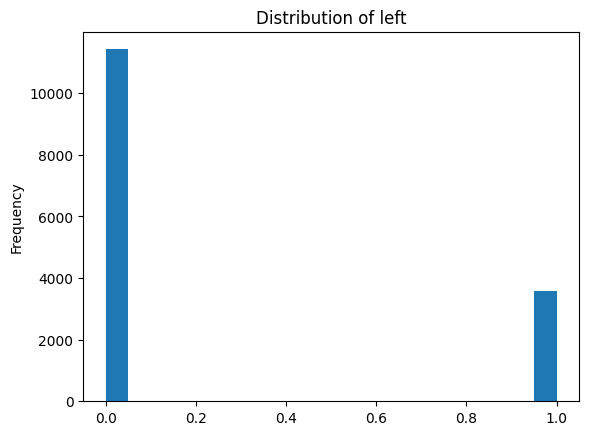

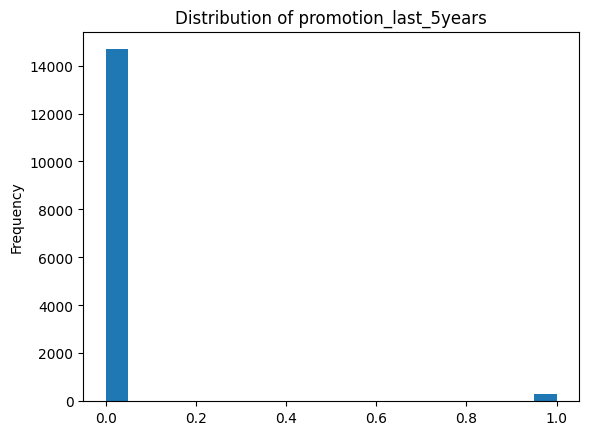

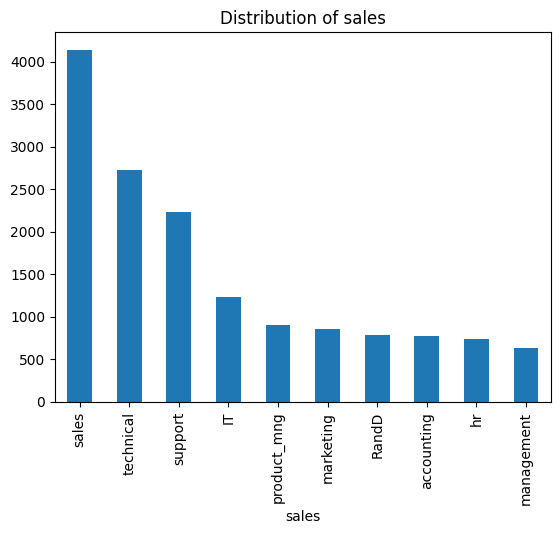

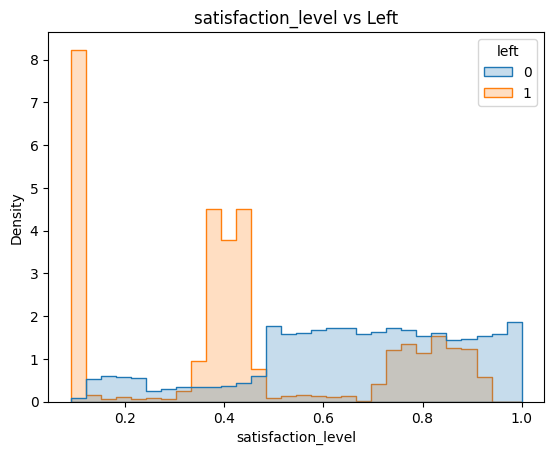

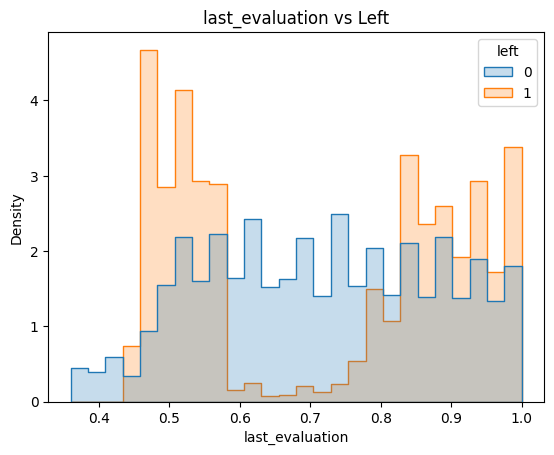

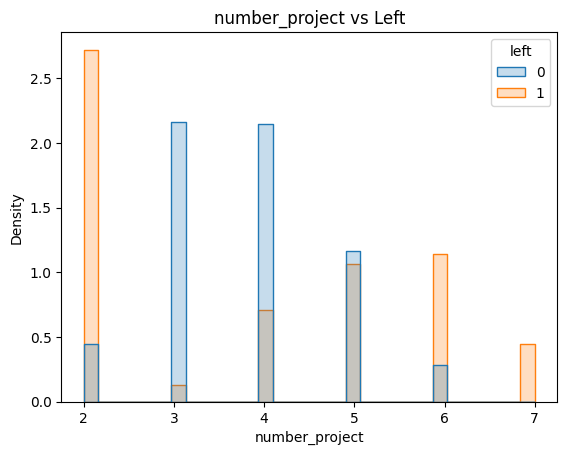

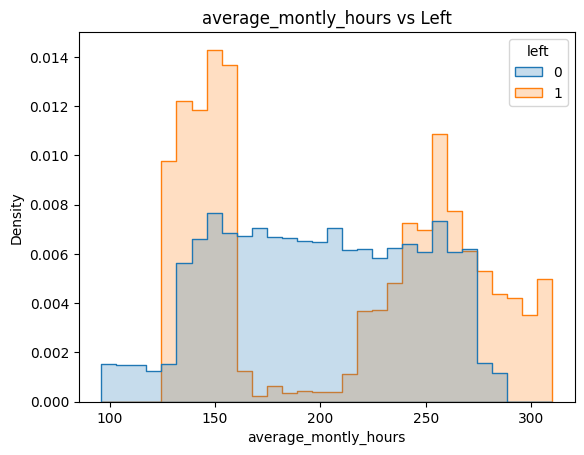

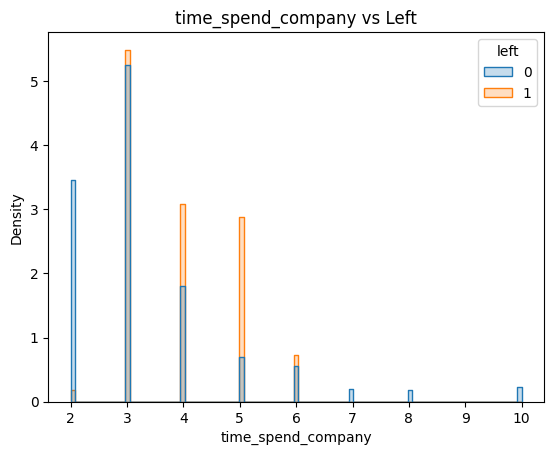

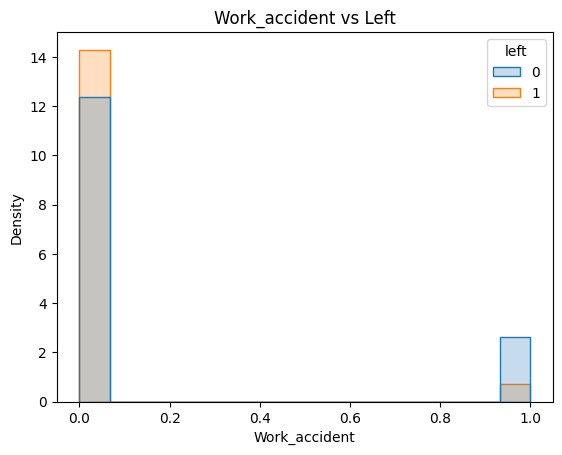

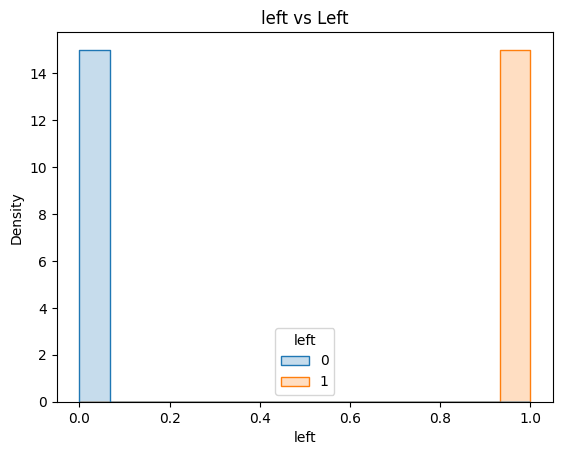

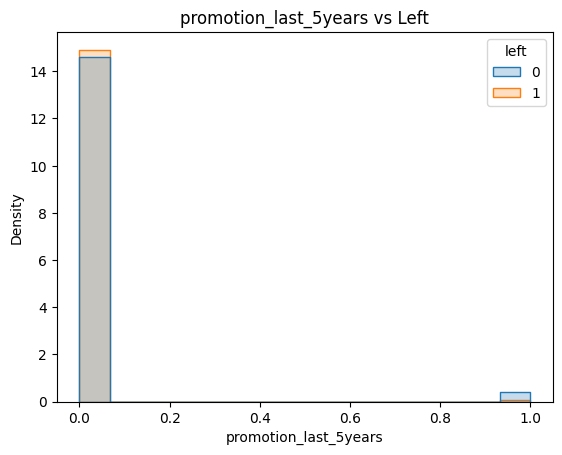

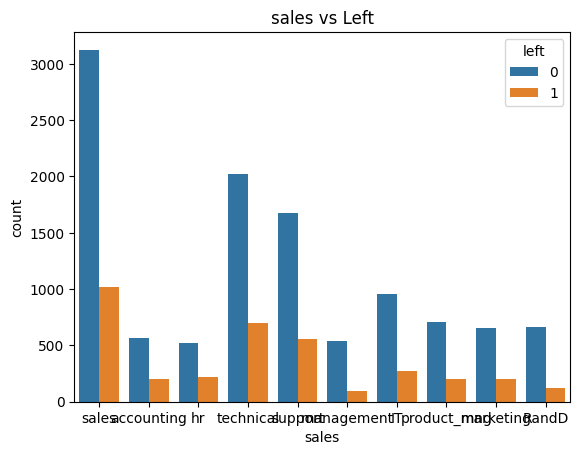

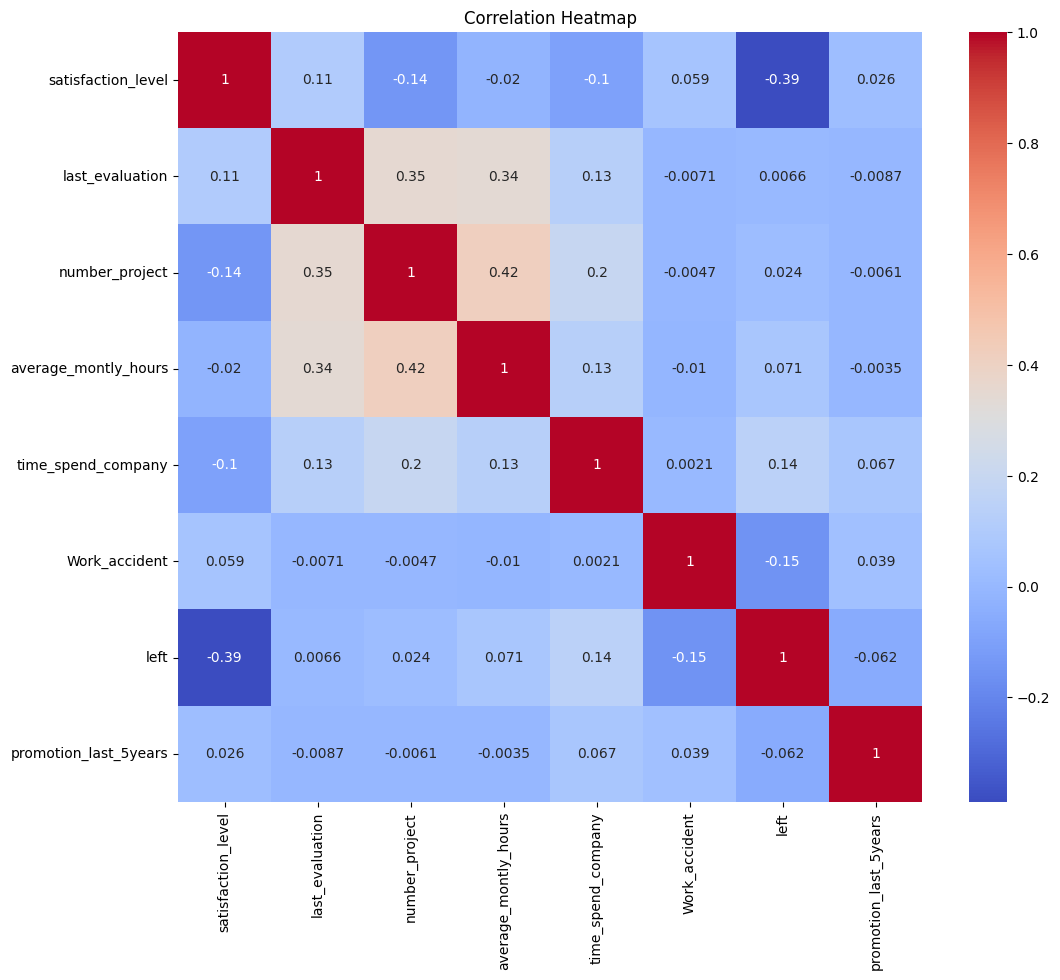

Accuracy: 0.9753
Precision: 0.9478
Recall: 0.9487
F1 Score: 0.9483


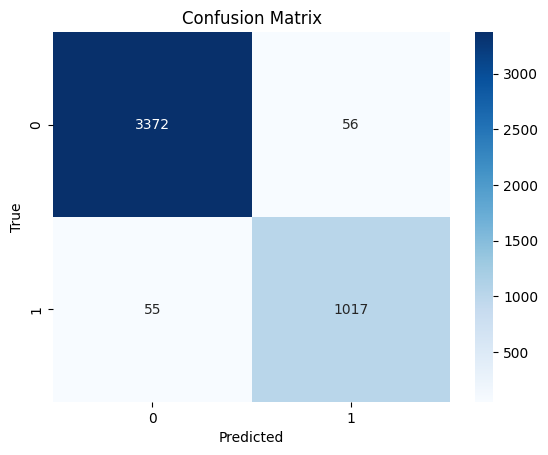

Classification Report for MLP:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3428
           1       0.95      0.95      0.95      1072

    accuracy                           0.98      4500
   macro avg       0.97      0.97      0.97      4500
weighted avg       0.98      0.98      0.98      4500


 Model Comparison:

    ML Technique  Accuracy  F1-score  Recall
0            MLP     97.53     94.83   94.87
1    Naive Bayes     79.91     62.86   71.36
2            SVM     95.67     90.72   88.90
3  Decision Tree     97.36     94.53   95.90


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load Dataset
data = pd.read_csv('/content/HR_comma_sep (1).csv')
print(data.head())

# 10 Random Samples
print(data.sample(10))

# Feature Distributions
features = data.columns[:-1]
for feature in features:
    plt.figure()
    if data[feature].dtype == 'object':
        data[feature].value_counts().plot(kind='bar')
    else:
        data[feature].plot(kind='hist', bins=20)
    plt.title(f'Distribution of {feature}')
    plt.show()

# Double Graphs (Feature vs Left)
for feature in features:
    plt.figure()
    if data[feature].dtype == 'object':
        sns.countplot(x=feature, hue='left', data=data)
    else:
        sns.histplot(data, x=feature, hue='left', element='step', stat='density', common_norm=False)
    plt.title(f'{feature} vs Left')
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Encode categorical features
label_encoders = {}
categorical_cols = data.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Split into features and labels
X = data.drop('left', axis=1)
y = data['left']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Build and Train MLP Model
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Predict and Metrics for MLP
y_pred = mlp.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report for MLP:")
print(classification_report(y_test, y_pred))

# MODEL COMPARISON
models = {
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": svm.SVC(),
    "Decision Tree": DecisionTreeClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_model) * 100
    f1 = f1_score(y_test, y_pred_model) * 100
    recall = recall_score(y_test, y_pred_model) * 100
    results.append([name, round(acc, 2), round(f1, 2), round(recall, 2)])

results_df = pd.DataFrame(results, columns=["ML Technique", "Accuracy", "F1-score", "Recall"])
print("\n Model Comparison:\n")
print(results_df)

# Final Assertions
assert data.shape[0] > 0, "Dataset is empty"
assert data.isnull().sum().sum() == 0, "Dataset has missing values"
assert len(mlp.coefs_) > 0, "Model was not trained!"
assert y_pred.shape == y_test.shape, "Mismatch between predictions and true labels!"
